In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('online_payment_fraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [22]:
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [34]:
"""
Exploratory Data Analysis — Online Payments Fraud Dataset
====================================================================
"""

# ---------------------------------------------------------------
# 2. BASIC STRUCTURE CHECKS
# ---------------------------------------------------------------
print("\n--- Missing values per column ---")
print(df.isnull().sum())

print("\n--- Duplicate rows ---")
print(df.duplicated().sum())

print("\n--- Summary statistics (numeric) ---")
print(df.describe())

print("\n--- Summary statistics (categorical) ---")
print(df.describe(include="object"))

# ---------------------------------------------------------------
# 3. TARGET VARIABLE: isFraud
# ---------------------------------------------------------------
print("\n--- Class balance (isFraud) ---")
fraud_counts = df["isFraud"].value_counts()
fraud_pct = df["isFraud"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": fraud_counts, "percent": fraud_pct.round(4)}))

plt.figure(figsize=(5, 4))
sns.countplot(x="isFraud", data=df)
plt.title("Class Balance: isFraud")
plt.yscale("log")  # log scale since fraud is rare
plt.tight_layout()
plt.savefig("eda_class_balance.png", dpi=150)
plt.close()

# Check isFlaggedFraud too, and how it relates to isFraud
if "isFlaggedFraud" in df.columns:
    print("\n--- isFlaggedFraud vs isFraud crosstab ---")
    print(pd.crosstab(df["isFlaggedFraud"], df["isFraud"]))




--- Missing values per column ---
step                  0
type                  0
amount                0
nameOrig              0
oldbalanceOrg         0
newbalanceOrig        0
nameDest              0
oldbalanceDest        0
newbalanceDest        0
isFraud               0
isFlaggedFraud        0
errorBalanceOrig      0
errorBalanceDest      0
hour_of_day           0
origAccountEmptied    0
dtype: int64

--- Duplicate rows ---
0

--- Summary statistics (numeric) ---
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    


--- Transaction type counts ---
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

--- Fraud rate by transaction type ---
          total_transactions  fraud_count  fraud_rate
type                                                 
TRANSFER              532909         4097    0.007688
CASH_OUT             2237500         4116    0.001840
CASH_IN              1399284            0    0.000000
DEBIT                  41432            0    0.000000
PAYMENT              2151495            0    0.000000


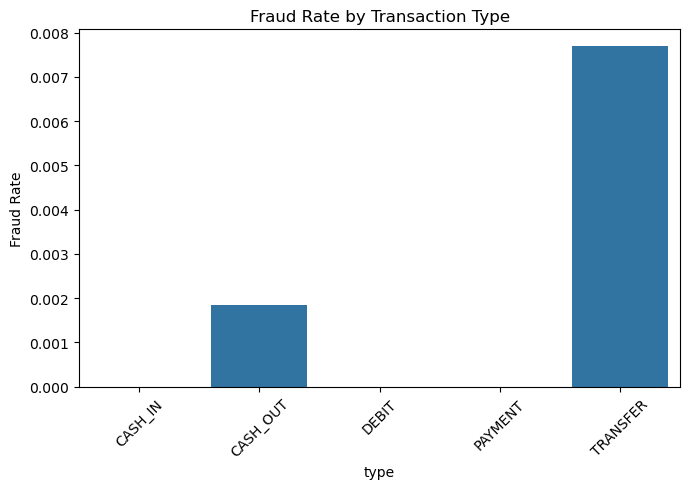

In [41]:
# ---------------------------------------------------------------
# 4. TRANSACTION TYPE ANALYSIS
# ---------------------------------------------------------------
print("\n--- Transaction type counts ---")
print(df["type"].value_counts())

print("\n--- Fraud rate by transaction type ---")
fraud_by_type = df.groupby("type")["isFraud"].agg(["count", "sum", "mean"])
fraud_by_type.columns = ["total_transactions", "fraud_count", "fraud_rate"]
print(fraud_by_type.sort_values("fraud_rate", ascending=False))

plt.figure(figsize=(7, 5))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type["fraud_rate"])
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

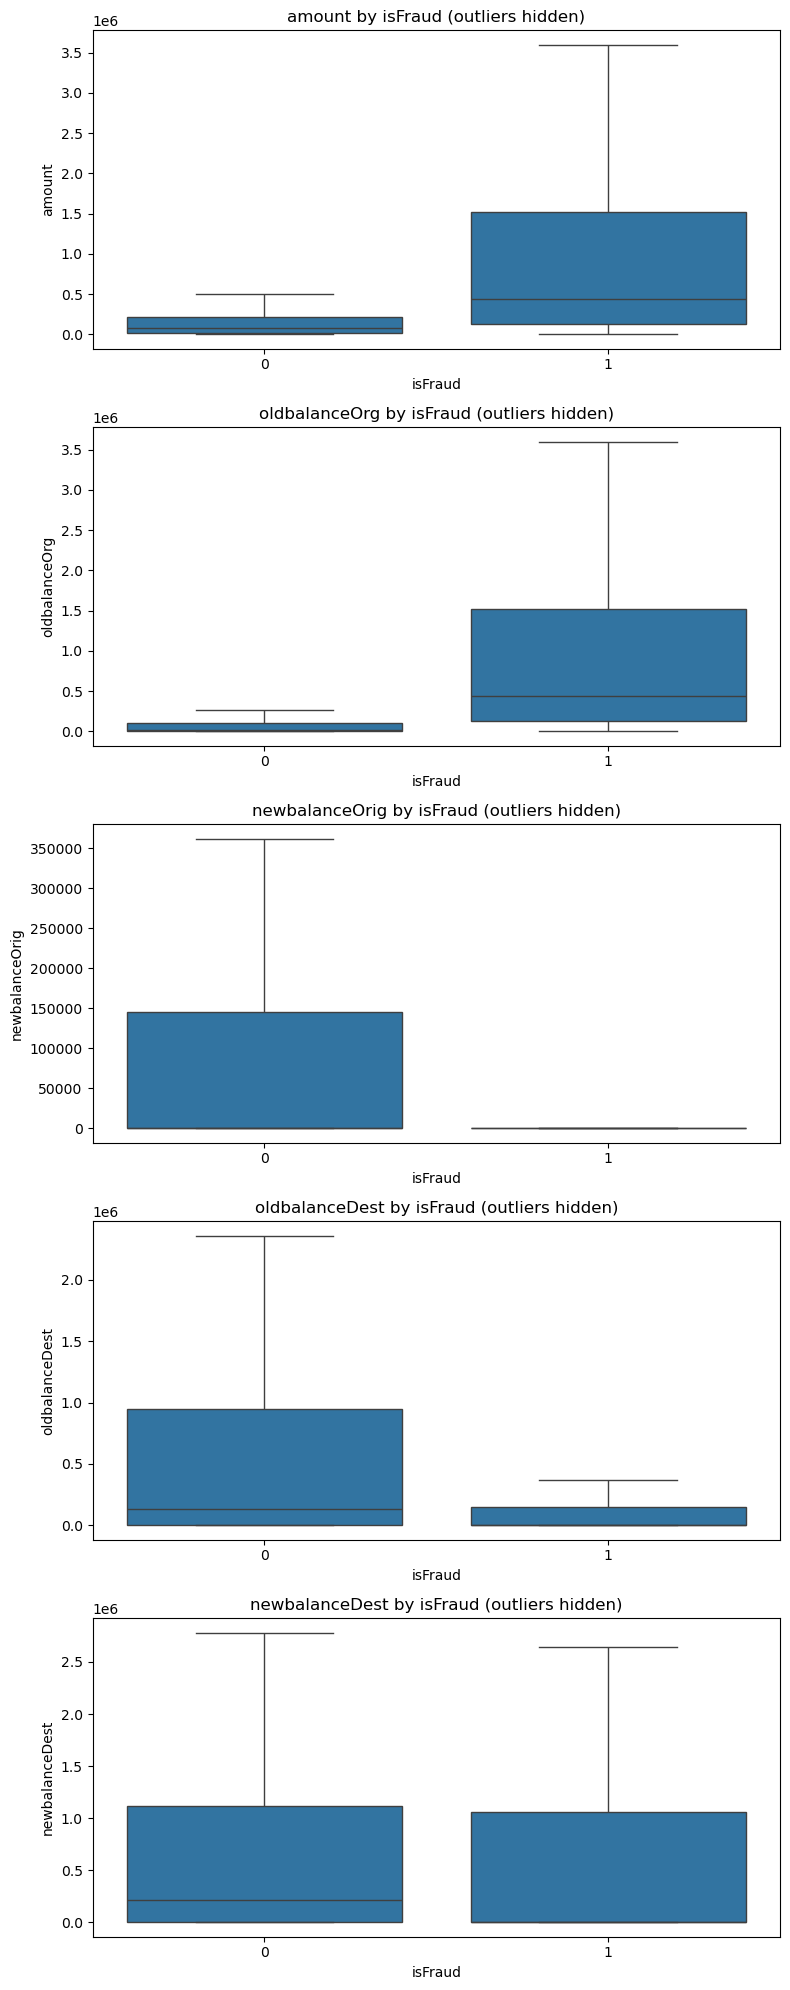


--- Numeric feature stats grouped by isFraud ---
isFraud                          0             1
amount         count  6.354407e+06  8.213000e+03
               mean   1.781970e+05  1.467967e+06
               std    5.962370e+05  2.404253e+06
               min    1.000000e-02  0.000000e+00
               25%    1.336840e+04  1.270913e+05
               50%    7.468472e+04  4.414234e+05
               75%    2.083648e+05  1.517771e+06
               max    9.244552e+07  1.000000e+07
oldbalanceOrg  count  6.354407e+06  8.213000e+03
               mean   8.328287e+05  1.649668e+06
               std    2.887144e+06  3.547719e+06
               min    0.000000e+00  0.000000e+00
               25%    0.000000e+00  1.258224e+05
               50%    1.406900e+04  4.389835e+05
               75%    1.069695e+05  1.517771e+06
               max    4.381886e+07  5.958504e+07
newbalanceOrig count  6.354407e+06  8.213000e+03
               mean   8.559702e+05  1.923926e+05
               std 

In [38]:
# ---------------------------------------------------------------
# 5. NUMERIC FEATURE DISTRIBUTIONS
# ---------------------------------------------------------------
numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
                 "oldbalanceDest", "newbalanceDest"]

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(8, 4 * len(numeric_cols)))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=100, ax=ax, log_scale=(False, True))
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("eda_numeric_distributions.png", dpi=150)
plt.close()

# Compare distributions: fraud vs non-fraud
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(8, 4 * len(numeric_cols)))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x="isFraud", y=col, data=df, ax=ax, showfliers=False)
    ax.set_title(f"{col} by isFraud (outliers hidden)")
plt.tight_layout()
plt.show()


print("\n--- Numeric feature stats grouped by isFraud ---")
print(df.groupby("isFraud")[numeric_cols].describe().T)


--- Error balance stats by isFraud ---
isFraud                            0             1
errorBalanceOrig count  6.354407e+06  8.213000e+03
                 mean  -2.013386e+05 -1.069233e+04
                 std    6.069289e+05  2.651461e+05
                 min   -9.244552e+07 -1.000000e+07
                 25%   -2.499534e+05  0.000000e+00
                 50%   -6.904931e+04  0.000000e+00
                 75%   -3.034305e+03  0.000000e+00
                 max    1.000000e-02  3.725290e-09
errorBalanceDest count  6.354407e+06  8.213000e+03
                 mean   5.469223e+04  7.325093e+05
                 std    4.360026e+05  1.867748e+06
                 min   -7.588573e+07 -8.875516e+06
                 25%    0.000000e+00  0.000000e+00
                 50%    3.500680e+03  2.231460e+03
                 75%    2.925981e+04  4.427220e+05
                 max    1.319123e+07  1.000000e+07

--- Step range ---
Min step: 1, Max step: 743


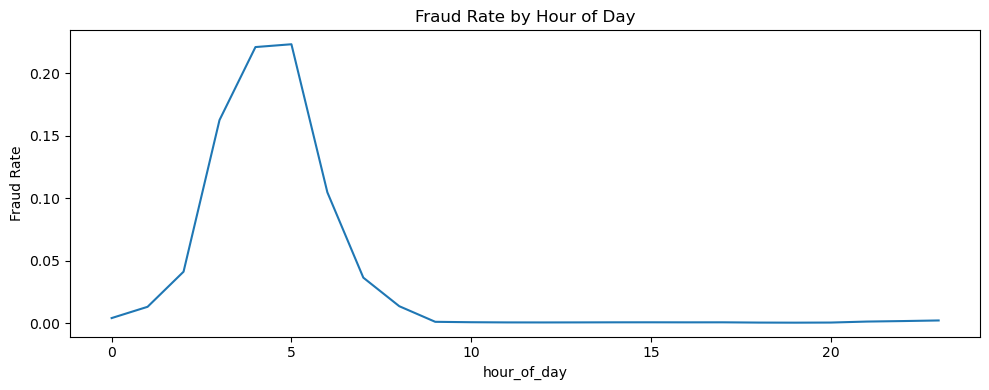

In [44]:
# ---------------------------------------------------------------
# 6. BALANCE CONSISTENCY / ERROR FEATURES
#    (Useful signals: mismatches between stated and actual balances)
# ---------------------------------------------------------------
df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

print("\n--- Error balance stats by isFraud ---")
print(df.groupby("isFraud")[["errorBalanceOrig", "errorBalanceDest"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="isFraud", y="errorBalanceOrig", data=df, ax=axes[0], showfliers=False)
sns.boxplot(x="isFraud", y="errorBalanceDest", data=df, ax=axes[1], showfliers=False)
axes[0].set_title("errorBalanceOrig by isFraud")
axes[1].set_title("errorBalanceDest by isFraud")
plt.tight_layout()
plt.savefig("eda_error_balances.png", dpi=150)
plt.close()

# ---------------------------------------------------------------
# 7. TIME (step) ANALYSIS
# ---------------------------------------------------------------
print("\n--- Step range ---")
print(f"Min step: {df['step'].min()}, Max step: {df['step'].max()}")

df["hour_of_day"] = df["step"] % 24

plt.figure(figsize=(10, 4))
sns.lineplot(data=df.groupby("hour_of_day")["isFraud"].mean())
plt.title("Fraud Rate by Hour of Day")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()





--- Fraud rate when origin account is emptied ---
origAccountEmptied
False    0.000042
True     0.005269
Name: isFraud, dtype: float64


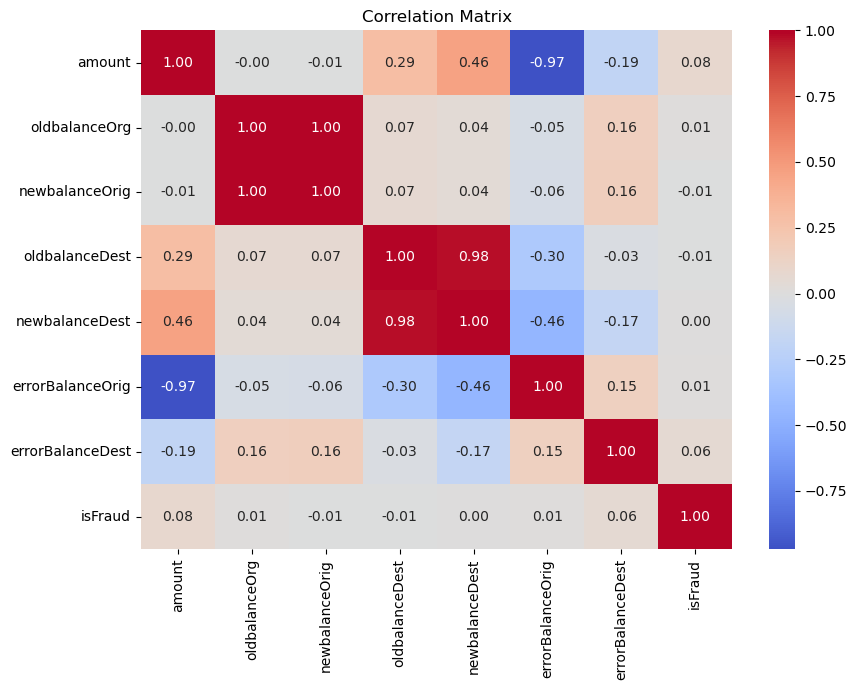

In [48]:
# ---------------------------------------------------------------
# 8. ZERO-BALANCE PATTERNS (common fraud signature: account drained)
# ---------------------------------------------------------------
df["origAccountEmptied"] = (df["newbalanceOrig"] == 0) & (df["oldbalanceOrg"] > 0)
print("\n--- Fraud rate when origin account is emptied ---")
print(df.groupby("origAccountEmptied")["isFraud"].mean())

# ---------------------------------------------------------------
# 9. CORRELATION MATRIX (numeric features only)
# ---------------------------------------------------------------
corr_cols = numeric_cols + ["errorBalanceOrig", "errorBalanceDest", "isFraud"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
